In [28]:
# Welcome to the benchmark Notebook to the CBMI NGS Pipeline Project
# pwd: /data/ldap/projekte/dtrinh_master/cbmi-dna-sequencing-wf/workflow/evaluation
# make sure to activate nix develop before running this notebook

In [29]:
import os
import glob
import pickle
import random
import shutil
import matplotlib.pyplot as plt
import pandas as pd

from ete3 import NCBITaxa
from pathlib import Path
from Bio import SeqIO
from sklearn.metrics import confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from pathlib import Path
import plotly.graph_objects as go

# Collecting pipeline statistics
Evaluation on which tool filters the most sequences averaging all eleven datasets.

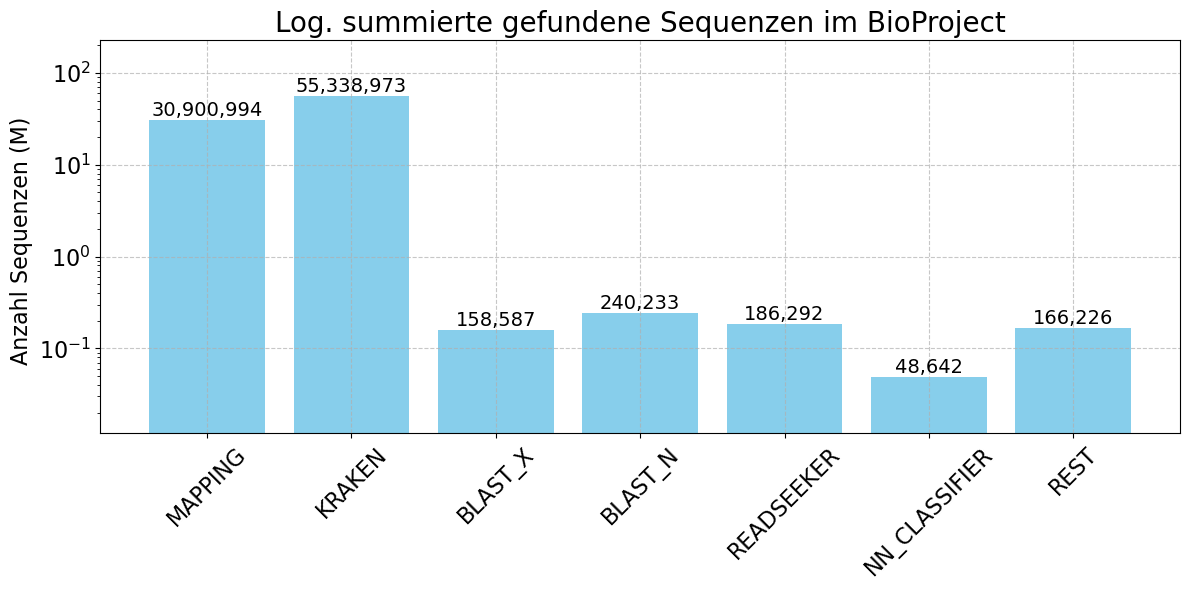

In [ ]:
# helpers

def collectReadcountFiles(filelist, plot=True):
    """
    Aggregate filtered reads from multiple CSVs and optionally plot results.

    Args:
        filelist (list): Paths to CSV files.
        plot (bool): If True, shows a bar plot (excluding 'raw').

    Returns:
        aggregated_df (DataFrame): All readings from all files.
        summary (Series): Total findings per tool (including 'raw').
    """
    all_dfs = []
    jobs = [
        "MAPPING", "KRAKEN", "BLAST_X", "BLAST_N", 
        "READSEEKER", "NN_CLASSIFIER", "REST"
    ]

    for file in filelist:
        df = pd.read_csv(file, header=None, names=["tool", "count"])
        df["findings"] = (df["count"].shift(1) - df["count"]).abs()
        df.loc[0, "findings"] = 0
        df["findings"] = df["findings"].astype(int)
        all_dfs.append(df)

    aggregated_df = pd.concat(all_dfs, ignore_index=True)
    summary = aggregated_df.groupby("tool")["findings"].sum()

    leftovers = aggregated_df[aggregated_df.tool == "nn-classifier"]["count"].sum()
    summary["rest"] = int(leftovers)

    summary.raw = summary.sum()


    if plot:
        tool_order = ["mapping", "kraken2", "blastx", "blastn", "readseeker", "nn-classifier", "rest"]
        plot_data = summary.drop(index="raw", errors="ignore").reindex(tool_order)

        plt.figure(figsize=(12,6))
        bars = plt.bar(plot_data.index, plot_data.values / 1e6, color="skyblue")

        y_ticks = plt.yticks()[0]
        plt.yticks(y_ticks, [f"{y:.1f}M" for y in y_ticks], fontsize=16)

        for bar, value in zip(bars, plot_data.values):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                     f"{value:,}", ha='center', va='bottom', fontsize=14)

        plt.margins(y=0.2)
        plt.yscale('log')
        plt.ylabel("Anzahl Sequenzen (M) ", fontsize=16)
        plt.title("Log. summierte gefundene Sequenzen im BioProject", fontsize=20)
        ticks = range(len(plot_data.index))
        plt.xticks(ticks=ticks, labels=jobs, rotation=45, fontsize=16)

        plt.tight_layout()

        plt.grid(axis='x', linestyle='--', alpha=0.7)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        
        plt.savefig("seq-barplot.png", dpi=300)
        
        plt.show()

    return aggregated_df, summary

readcount_paths = sorted(glob.glob("../data/SRR*/readscount.csv", recursive=True))
df_seq, summary = collectReadcountFiles(readcount_paths, plot=True)

In [32]:
print("Remaining percentage: ", summary.rest / summary.raw * 100)

Remaining percentage:  0.1909766787886486


In [33]:
def format_hms(td):
    total_seconds = int(td.total_seconds())
    hours = total_seconds // 3600
    minutes = (total_seconds % 3600) // 60
    seconds = total_seconds % 60
    return f"{hours:02}:{minutes:02}:{seconds:02}"

# collect times
# calculate runtime for each process. include download and fasterq conversion
def collectTraceFiles(trace_files):
    task_filter = [
        "FETCH_ACCESSION", "FASTERQ", "MAPPING", 
        "KRAKEN", "BLAST_X", "BLAST_N", "READSEEKER", "NN_CLASSIFIER"
    ]
    
    dfs = []
    for file in trace_files:
        df = pd.read_csv(file, sep="\t", engine="python", on_bad_lines="skip")
        df["source_file"] = Path(file).name
        dfs.append(df)

    df_all = pd.concat(dfs, ignore_index=True)
    pattern = r"\b(?:" + "|".join(task_filter) + r")\b"
    df_all = df_all[df_all["name"].str.contains(pattern)].copy()
    df_all["task_name"] = df_all["name"].str.extract(r"^(\w+)")
    df_all["duration_td"] = pd.to_timedelta(df_all["duration"])
    df_times_processes = df_all.groupby("task_name", as_index=False)["duration_td"].mean()
    df_times_processes["duration_hms"] = df_times_processes["duration_td"].apply(lambda td: str(td).split()[ -1].split('.')[0])
    
    df_times_processes["task_name"] = pd.Categorical(df_times_processes["task_name"], categories=task_filter, ordered=True)
    df_times_processes = df_times_processes.sort_values("task_name").reset_index(drop=True)
    df_times_processes = df_times_processes[["task_name", "duration_td", "duration_hms"]]

    return df_times_processes

df_times = collectTraceFiles(trace_paths)
df_times

,task_name,duration_td,duration_hms
0,FETCH_ACCESSION,0 days 00:03:00,00:03:00
1,FASTERQ,0 days 00:03:01.227272727,00:03:01
2,MAPPING,0 days 00:25:59.727272727,00:25:59
3,KRAKEN,0 days 00:24:02.181818181,00:24:02
4,BLAST_X,0 days 00:01:22.200000,00:01:22
5,BLAST_N,0 days 03:41:24.272727272,03:41:24
6,READSEEKER,0 days 01:11:55.727272727,01:11:55
7,NN_CLASSIFIER,0 days 01:07:57.454545454,01:07:57


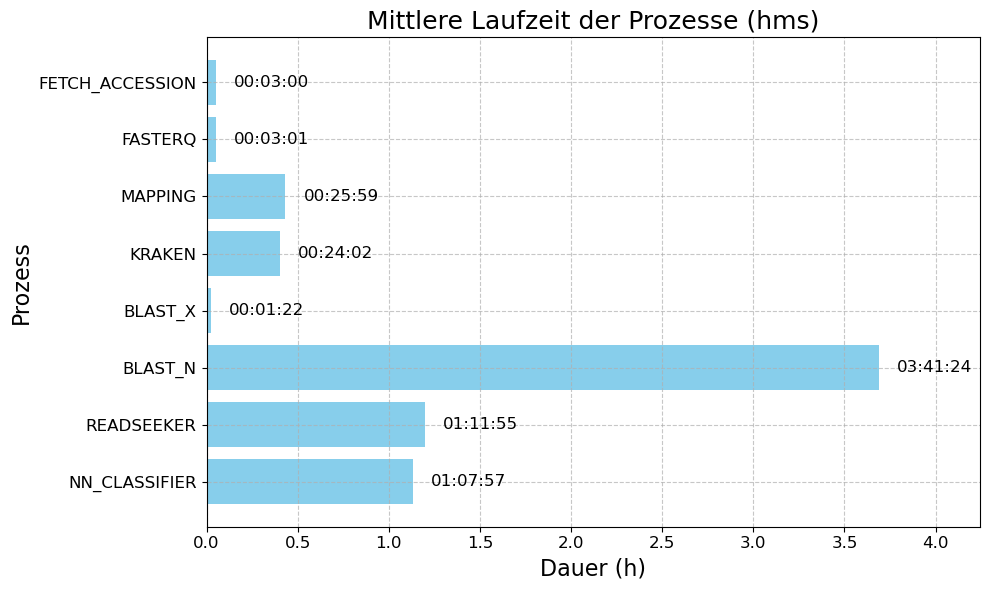

In [34]:
plt.figure(figsize=(10, 6))

bars = plt.barh(
    df_times["task_name"],
    df_times["duration_td"].dt.total_seconds()/3600,  # Breite in Stunden
    color="skyblue"
)

for bar, td in zip(bars, df_times["duration_td"]):
    width = bar.get_width()
    label = format_hms(td)
    plt.text(width + 0.1, bar.get_y() + bar.get_height()/2, label, va="center", fontsize=12)

max_hours = df_times["duration_td"].dt.total_seconds().max() / 3600
plt.xlim(0, max_hours * 1.15)

plt.title("Mittlere Laufzeit der Prozesse (hms)", fontsize=18)

plt.xlabel("Dauer (h)", fontsize=16)
plt.ylabel("Prozess", fontsize=16)
plt.gca().invert_yaxis()

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.yticks(fontsize=12)
plt.xticks(fontsize=12)

plt.tight_layout()
plt.savefig("times-plot.png", dpi=300)
plt.show()


# D: Blast N dauert so lange, weil die Referenzdatenbank sehr groß ist. 
# D: Unabhängig von den Eingabedaten, dauert der Prozess lange, weil die komplette DB eingeladen werden muss
# D: Kommulierte Laufzeit des Prozesses allein beträgt über 40h 



In [35]:
# Simulated Slurm run: process eleven accession ids on 8 nodes
# Some nodes get bigger .sra files than others to distribute size more evenly 
# Runtimes gathered from nextflow log cmd

data = [
    ("7h 34m 13s", "focused_mclean", "SRR35359597", 2.6, 1),
    ("7h 4m 48s", "insane_bohr", "SRR35359603", 2.2, 1),
    ("5h 25m 59s", "suspicious_majorana", "SRR35359596", 1.9, 1),
    ("8h 3m 33s", "pensive_rosalind", "SRR35359601", 1.1, 1),
    ("12h 4m 18s", "awesome_celsius", "SRR35359599", 3, 1),
    ("9h 7m 5s", "intergalactic_dalembert", "SRR35359595, SRR35359602", 1.3 + 0.89, 2),
    ("15h 29m 14s", "golden_lamarr", "SRR35359598, SRR35359604", 0.4329+ 0.1942, 2),
    ("11h 51m 49s", "high_meninsky", "SRR35359600, SRR35359594", 0.1613 + 0.1318, 2)
]

df = pd.DataFrame(data, columns=["duration_str", "run_name", "accessions", "size (Gb)", "#acc"])
df["node"] = [f"p{i:02d}" for i in range(3, 11)]

df["duration_td"] = pd.to_timedelta(df["duration_str"])
df["duration_hms"] = df["duration_td"].apply(lambda td: str(td).split()[-1].split(".")[0])
df["duration_td"] = pd.to_timedelta(df["duration_str"])
df["duration_hms"] = df["duration_td"].apply(
    lambda td: str(td).split()[-1].split(".")[0]
)

df["node"] = df["node"].astype(str)
df.loc[:4, "node"] = df.loc[:4, "node"] + " (1)"
df.loc[5:, "node"] = df.loc[5:, "node"] + " (2)"

df


,duration_str,run_name,accessions,size (Gb),#acc,node,duration_td,duration_hms
0,7h 34m 13s,focused_mclean,SRR35359597,2.6000,1,p03 (1),0 days 07:34:13,07:34:13
1,7h 4m 48s,insane_bohr,SRR35359603,2.2000,1,p04 (1),0 days 07:04:48,07:04:48
2,5h 25m 59s,suspicious_majorana,SRR35359596,1.9000,1,p05 (1),0 days 05:25:59,05:25:59
3,8h 3m 33s,pensive_rosalind,SRR35359601,1.1000,1,p06 (1),0 days 08:03:33,08:03:33
4,12h 4m 18s,awesome_celsius,SRR35359599,3.0000,1,p07 (1),0 days 12:04:18,12:04:18
5,9h 7m 5s,intergalactic_dalembert,"SRR35359595, SRR35359602",2.1900,2,p08 (2),0 days 09:07:05,09:07:05
6,15h 29m 14s,golden_lamarr,"SRR35359598, SRR35359604",0.6271,2,p09 (2),0 days 15:29:14,15:29:14
7,11h 51m 49s,high_meninsky,"SRR35359600, SRR35359594",0.2931,2,p10 (2),0 days 11:51:49,11:51:49


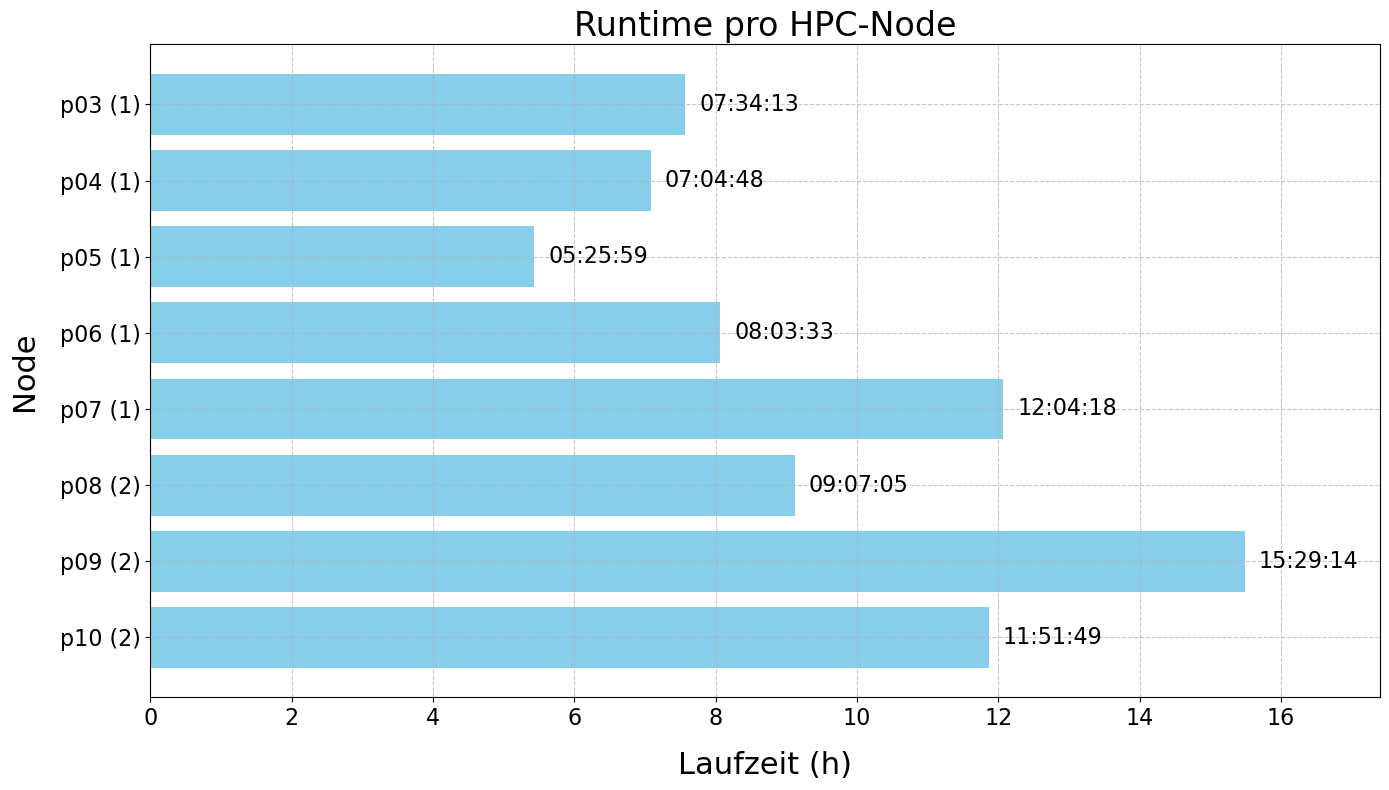

In [36]:
fig, ax = plt.subplots(figsize=(14, 8))

# Balkenplot
bars = ax.barh(
    df["node"],
    df["duration_td"].dt.total_seconds() / 3600,
    color="skyblue"
)

for bar, hms in zip(bars, df["duration_hms"]):
    ax.text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height() / 2,
        hms,
        va="center",
        fontsize=16
    )


#plt.xlabel("Dauer (h)", fontsize=22)
#plt.ylabel("Node", fontsize=22)
ax.set_xlabel("Laufzeit (h)", fontsize=22, labelpad=15)
ax.set_ylabel("Node", fontsize=22, labelpad=15)
ax.set_title("Runtime pro HPC-Node", fontsize=24)

ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)
ax.set_xlim(0, ax.get_xlim()[1] * 1.07)

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.gca().invert_yaxis()


plt.savefig("hpc-runtime-plot",dpi=300)

plt.tight_layout()
plt.show()


# Robustness analysis against unknown references 
This analysis checks if the pipeline is correctly not removing sequences of unknown referencegenomes.

- test accession: SRR36854087	
- test viral fasta: SRR36854087	
- removed all sequences containing "Corona" and ""

The databases build for kraken2, blastn and diamond is documented with step-by-step pseudo code
It is recommended to run these commands inside the terminal and from inside the jupyter notebook.
The "test viral fasta" is used to build the databases.

After the ngs pipeline will start with both database settings (regular vs experimental) manually inside the termial with:

#### nf-test test --filter pipeline --verbose

to generate the readscount.csv

## Filter Input FASTA for All Databases

Download the original viral FASTA from NCBI:

**`https://ftp.ncbi.nlm.nih.gov/refseq/release/viral/viral.1.1.genomic.fna.gz`**

Remove all sequences containing "Corona" from the input FASTA file:

**`seqkit grep --by-name --use-regexp --invert-match --ignore-case --pattern "Corona" experimental-db/viral.1.1.genomic.fna > experimental-db/experimental_db.fna`**

 **`experimental_db.fna`** is the **`<path-to-fasta>`** for each of the following database builds


## Pseudo-Code: Building a Kraken2 Database

### 1. Create Folder Structure

First, create the necessary folders. 

**`mkdir -p experimental-db/kraken2/experimental/taxonomy`**

This path equals $DBNAME:

**`mkdir -p experimental-db/kraken2/experimental/taxonomy`**

---

### 2. Download and Extract Taxonomy Files and store inside /taxonomy

Download `nodes.dmp` and `names.dmp` to /taxonomy inside k2 db folder:

**`wget https://ftp.ncbi.nlm.nih.gov/pub/taxonomy/taxdump.tar.gz | tar -xz -C /taxonomy nodes.dmp names.dmp`**

A mapping file is needed to convert from NCBI taxids to kraken2 taxids

**`wget https://ftp.ncbi.nlm.nih.gov/pub/taxonomy/accession2taxid/nucl_gb.accession2taxid.gz | gzip nucl_gb.accession2taxid.gz`**

---

### 3. Add custom Fasta file to database library:

Add (corona sequences) reduced experimental_db.fna to krakenk2 db. Make sure to use the singularity image. Here <fasta-path> is experimental-db/experimental_db.fna file

**`singularity exec -B /data/ <path-to-k2-sif> kraken2-build --add-to-library <path-to-fasta> --db $DBNAME`**

---

### 4. Build the Kraken2 Database

Build kraken2 database with:

**`singularity exec -B /data/ <path-to-k2-sif> kraken2-build --build --db $DBNAME`**



## Pseudo-Code: Building a Blastn Database

### Run the following command 

**`singularity exec -B /data/ <path-to-blast-sif> makeblastdb -in <path-to-fasta> -dbtype nucl -out <path-to-custom-db>`**


## Pseudo-Code: Building a DIAMOND Database

### Run the following command

**`singularity exec -B /data/ <path-to-diamond-sif> diamond makedb --in <path-to-fasta> -d <path-to-custom-db>`**


## Run the nf-test Pipeline

Run the `nf-test` pipeline in verbose mode with filtering enabled, specifying an accession and the two database configurations:

**`nf-test test --filter pipeline --verbose`**

to generate these results: 


#### Normal Database Analysis

| Step      | Count     |
|-----------|----------|
| raw       | 957,026  |
| mapping   | 810,634  |
| kraken2   | 779      |
| diamond   | 211      |
| blastn    | 71       |

---

#### Experimental Databases Analysis

| Step      | Count     |
|-----------|----------|
| raw       | 957,026  |
| mapping   | 810,634  |
| kraken2   | 806,583  |
| blastx    | 616,587  |
| blastn    | 615,026  |
